In [2]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib

RANDOM_STATE = 42

In [3]:
column_names = [
    'age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholesterol_level',
    'fasting_blood_sugar', 'resting_ecg_result', 'maximum_heart_rate_achieved',
    'exercise_induced_chest_pain', 'st_depression_during_exercise', 'slope_of_exercise_ecg',
    'number_of_major_vessels', 'thalassemia_test_result', 'heart_disease_severity'
]

# The raw file has NO header row - reading it with defaults would silently treat the
# first patient's record as column names and drop that row from the dataset.
# header=None + explicit `names` fixes this and keeps all 303 rows.
data = pd.read_csv(
    '/kaggle/input/datasets/muhammadhassanazad/heart-disease/processed.cleveland.data',
    header=None,
    names=column_names
)
data.tail(10)

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol_level,fasting_blood_sugar,resting_ecg_result,maximum_heart_rate_achieved,exercise_induced_chest_pain,st_depression_during_exercise,slope_of_exercise_ecg,number_of_major_vessels,thalassemia_test_result,heart_disease_severity
293,63.0,1.0,4.0,140.0,187.0,0.0,2.0,144.0,1.0,4.0,1.0,2.0,7.0,2
294,63.0,0.0,4.0,124.0,197.0,0.0,0.0,136.0,1.0,0.0,2.0,0.0,3.0,1
295,41.0,1.0,2.0,120.0,157.0,0.0,0.0,182.0,0.0,0.0,1.0,0.0,3.0,0
296,59.0,1.0,4.0,164.0,176.0,1.0,2.0,90.0,0.0,1.0,2.0,2.0,6.0,3
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [4]:
data.head(2)

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol_level,fasting_blood_sugar,resting_ecg_result,maximum_heart_rate_achieved,exercise_induced_chest_pain,st_depression_during_exercise,slope_of_exercise_ecg,number_of_major_vessels,thalassemia_test_result,heart_disease_severity
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            303 non-null    float64
 1   sex                            303 non-null    float64
 2   chest_pain_type                303 non-null    float64
 3   resting_blood_pressure         303 non-null    float64
 4   cholesterol_level              303 non-null    float64
 5   fasting_blood_sugar            303 non-null    float64
 6   resting_ecg_result             303 non-null    float64
 7   maximum_heart_rate_achieved    303 non-null    float64
 8   exercise_induced_chest_pain    303 non-null    float64
 9   st_depression_during_exercise  303 non-null    float64
 10  slope_of_exercise_ecg          303 non-null    float64
 11  number_of_major_vessels        303 non-null    object 
 12  thalassemia_test_result        303 non-null    obj

In [5]:
data[['number_of_major_vessels', 'thalassemia_test_result']] = data[['number_of_major_vessels', 'thalassemia_test_result']].apply(pd.to_numeric, errors='coerce') 

In [6]:
data.shape

(303, 14)

In [7]:
data.isnull().mean()*100

age                              0.000000
sex                              0.000000
chest_pain_type                  0.000000
resting_blood_pressure           0.000000
cholesterol_level                0.000000
fasting_blood_sugar              0.000000
resting_ecg_result               0.000000
maximum_heart_rate_achieved      0.000000
exercise_induced_chest_pain      0.000000
st_depression_during_exercise    0.000000
slope_of_exercise_ecg            0.000000
number_of_major_vessels          1.320132
thalassemia_test_result          0.660066
heart_disease_severity           0.000000
dtype: float64

In [8]:
data['heart_disease_severity'].value_counts()

heart_disease_severity
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [9]:
data['number_of_major_vessels'].sample(10)

163    0.0
62     3.0
135    0.0
71     2.0
265    0.0
153    1.0
109    0.0
111    1.0
186    0.0
254    0.0
Name: number_of_major_vessels, dtype: float64

In [10]:
data['thalassemia_test_result'].sample(10)

33     7.0
280    7.0
217    3.0
175    7.0
43     3.0
31     7.0
1      3.0
289    3.0
235    3.0
128    3.0
Name: thalassemia_test_result, dtype: float64

In [11]:
data.describe()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol_level,fasting_blood_sugar,resting_ecg_result,maximum_heart_rate_achieved,exercise_induced_chest_pain,st_depression_during_exercise,slope_of_exercise_ecg,number_of_major_vessels,thalassemia_test_result,heart_disease_severity
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


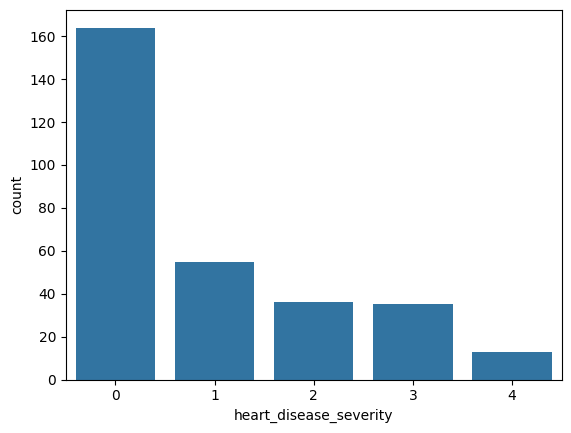

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=data['heart_disease_severity'])
plt.show()

In [13]:
data.corr()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol_level,fasting_blood_sugar,resting_ecg_result,maximum_heart_rate_achieved,exercise_induced_chest_pain,st_depression_during_exercise,slope_of_exercise_ecg,number_of_major_vessels,thalassemia_test_result,heart_disease_severity
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.362605,0.127389,0.222853
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.093185,0.380936,0.224469
chest_pain_type,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233214,0.265246,0.407075
resting_blood_pressure,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.098773,0.133554,0.157754
cholesterol_level,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.119000,0.014214,0.070909
fasting_blood_sugar,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.145478,0.071358,0.059186
resting_ecg_result,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.128343,0.024531,0.183696
maximum_heart_rate_achieved,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.264246,-0.279631,-0.415040
exercise_induced_chest_pain,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145570,0.329680,0.397057
st_depression_during_exercise,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.295832,0.341004,0.504092


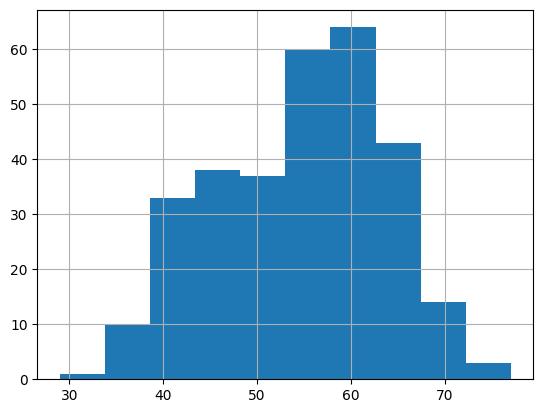

In [14]:

data['age'].hist()
plt.show()

In [15]:
data.max()

age                               77.0
sex                                1.0
chest_pain_type                    4.0
resting_blood_pressure           200.0
cholesterol_level                564.0
fasting_blood_sugar                1.0
resting_ecg_result                 2.0
maximum_heart_rate_achieved      202.0
exercise_induced_chest_pain        1.0
st_depression_during_exercise      6.2
slope_of_exercise_ecg              3.0
number_of_major_vessels            3.0
thalassemia_test_result            7.0
heart_disease_severity             4.0
dtype: float64

In [16]:
data.min()

age                               29.0
sex                                0.0
chest_pain_type                    1.0
resting_blood_pressure            94.0
cholesterol_level                126.0
fasting_blood_sugar                0.0
resting_ecg_result                 0.0
maximum_heart_rate_achieved       71.0
exercise_induced_chest_pain        0.0
st_depression_during_exercise      0.0
slope_of_exercise_ecg              1.0
number_of_major_vessels            0.0
thalassemia_test_result            3.0
heart_disease_severity             0.0
dtype: float64

In [17]:
data.mean()

age                               54.438944
sex                                0.679868
chest_pain_type                    3.158416
resting_blood_pressure           131.689769
cholesterol_level                246.693069
fasting_blood_sugar                0.148515
resting_ecg_result                 0.990099
maximum_heart_rate_achieved      149.607261
exercise_induced_chest_pain        0.326733
st_depression_during_exercise      1.039604
slope_of_exercise_ecg              1.600660
number_of_major_vessels            0.672241
thalassemia_test_result            4.734219
heart_disease_severity             0.937294
dtype: float64

In [18]:
data['number_of_major_vessels'].value_counts(dropna=False)

number_of_major_vessels
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4
Name: count, dtype: int64

In [19]:
data['thalassemia_test_result'].value_counts(dropna=False)

thalassemia_test_result
3.0    166
7.0    117
6.0     18
NaN      2
Name: count, dtype: int64

In [20]:
vessels = data['number_of_major_vessels'].mode()[0]
data['number_of_major_vessels'] = data['number_of_major_vessels'].fillna(vessels)
print(vessels)

thalassemia = data['thalassemia_test_result'].mode()[0]
data['thalassemia_test_result'] = data['thalassemia_test_result'].fillna(thalassemia)
print(thalassemia)

0.0
3.0


In [21]:
data.head(5)

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol_level,fasting_blood_sugar,resting_ecg_result,maximum_heart_rate_achieved,exercise_induced_chest_pain,st_depression_during_exercise,slope_of_exercise_ecg,number_of_major_vessels,thalassemia_test_result,heart_disease_severity
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            303 non-null    float64
 1   sex                            303 non-null    float64
 2   chest_pain_type                303 non-null    float64
 3   resting_blood_pressure         303 non-null    float64
 4   cholesterol_level              303 non-null    float64
 5   fasting_blood_sugar            303 non-null    float64
 6   resting_ecg_result             303 non-null    float64
 7   maximum_heart_rate_achieved    303 non-null    float64
 8   exercise_induced_chest_pain    303 non-null    float64
 9   st_depression_during_exercise  303 non-null    float64
 10  slope_of_exercise_ecg          303 non-null    float64
 11  number_of_major_vessels        303 non-null    float64
 12  thalassemia_test_result        303 non-null    flo

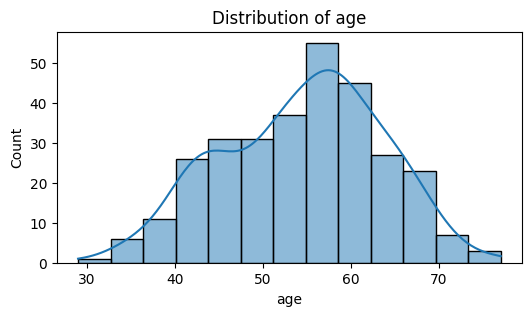

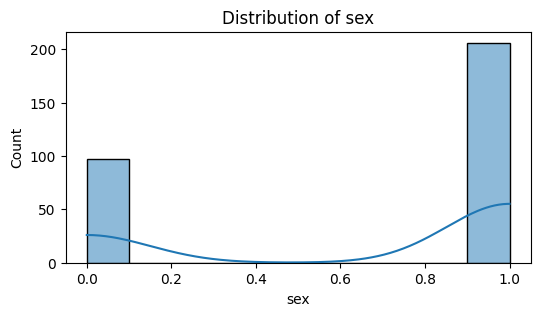

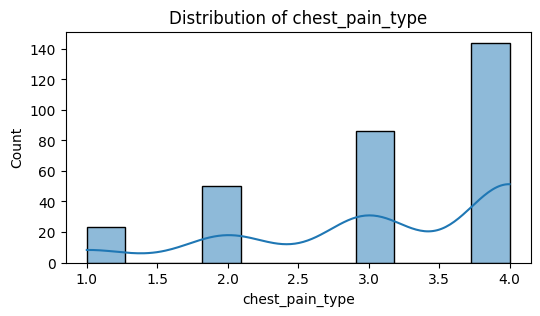

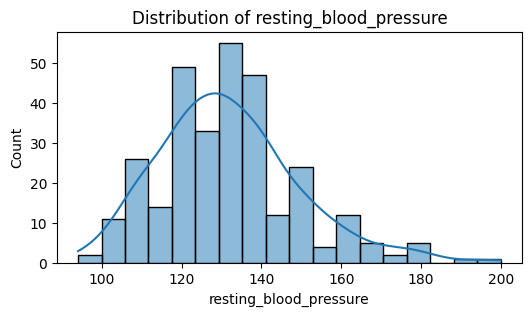

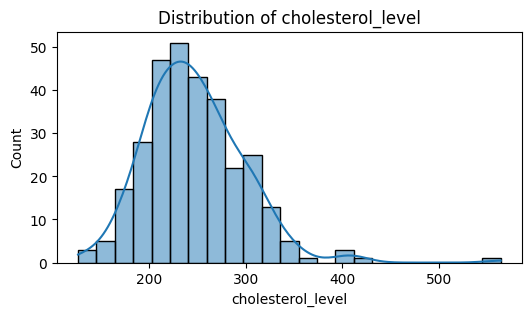

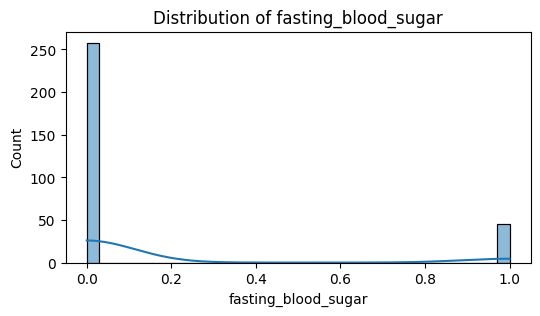

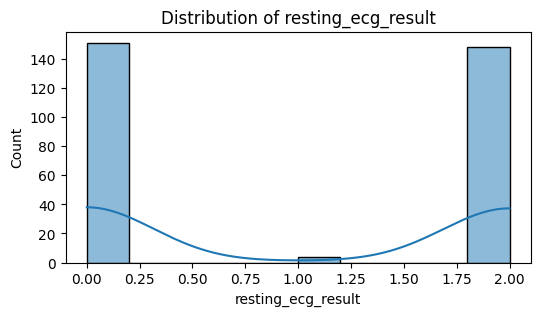

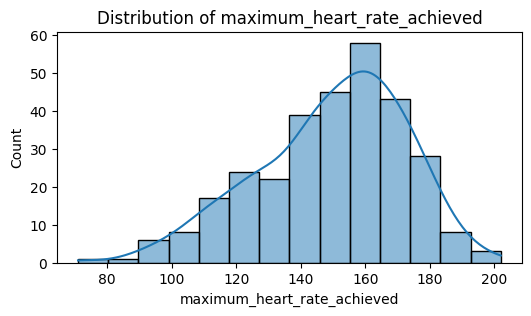

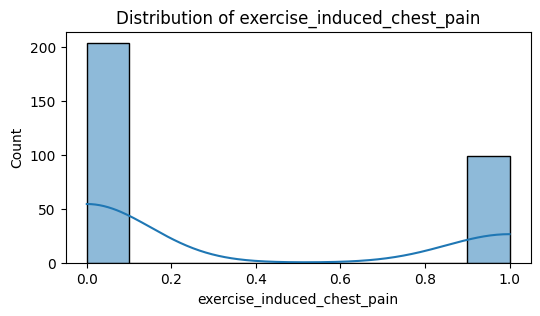

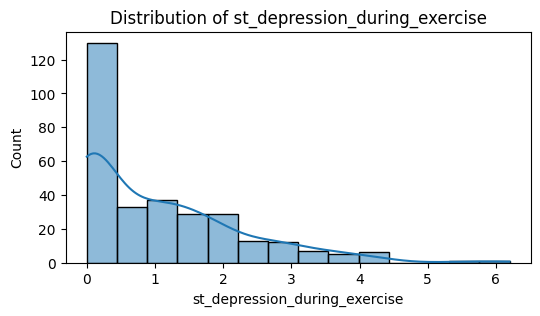

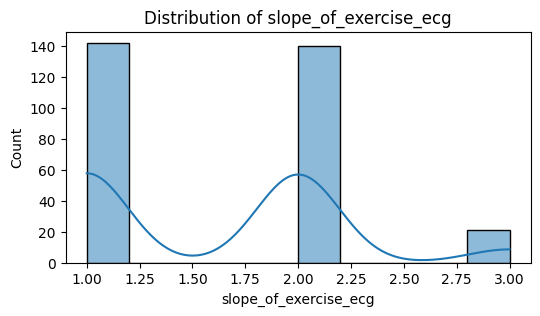

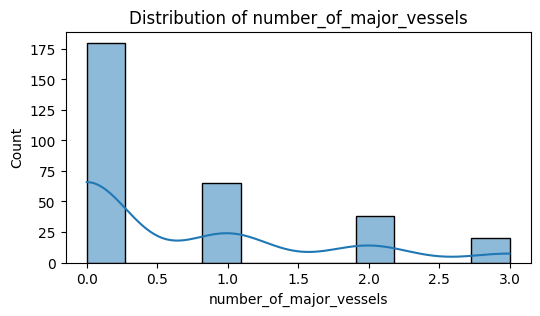

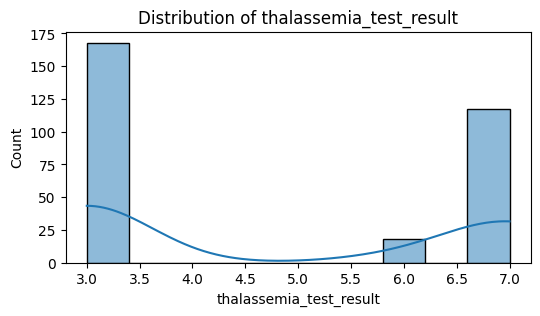

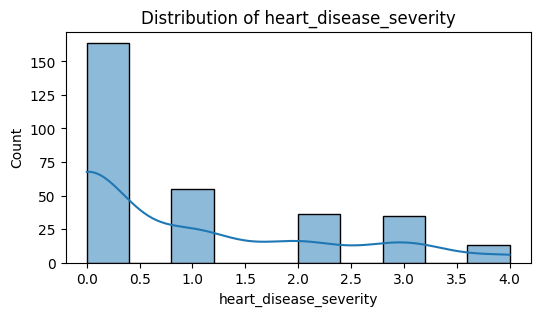

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot all columns to visualize symmetry and extreme values
for col in data.columns:
    plt.figure(figsize=(6, 3))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

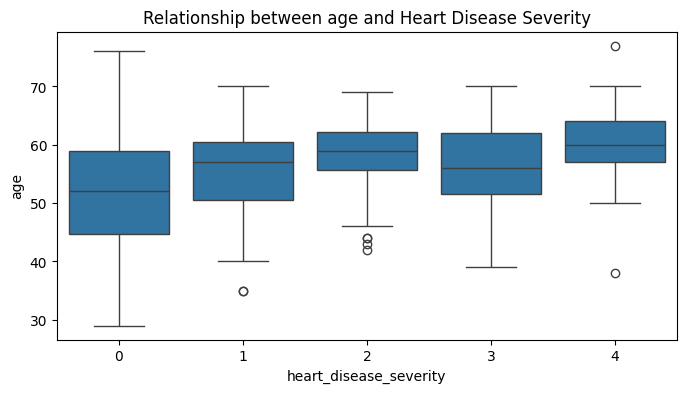

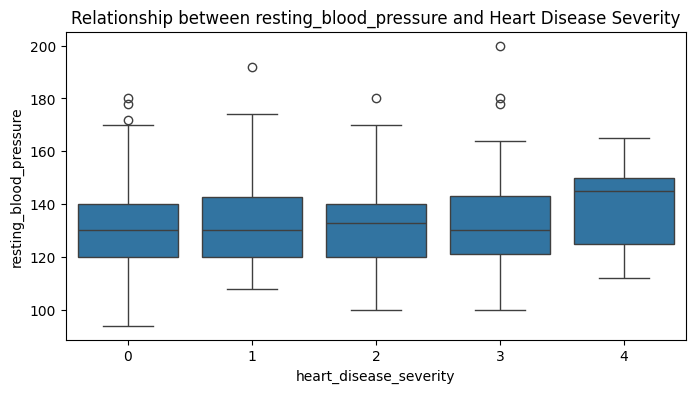

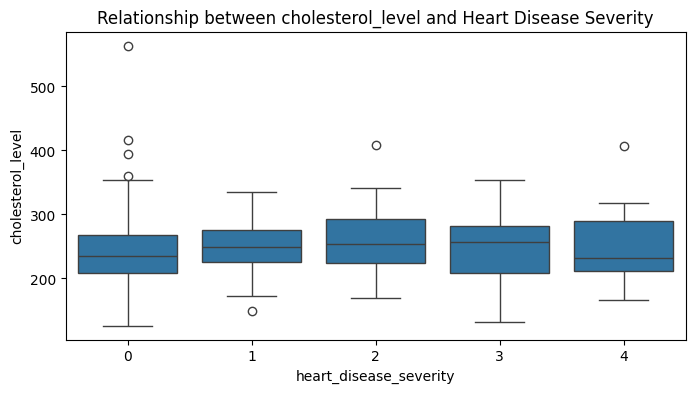

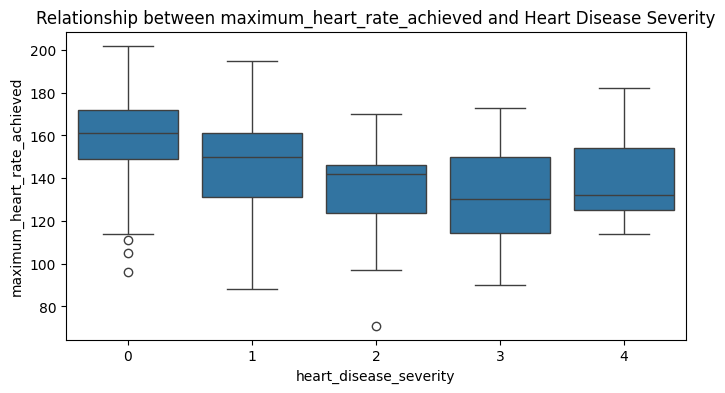

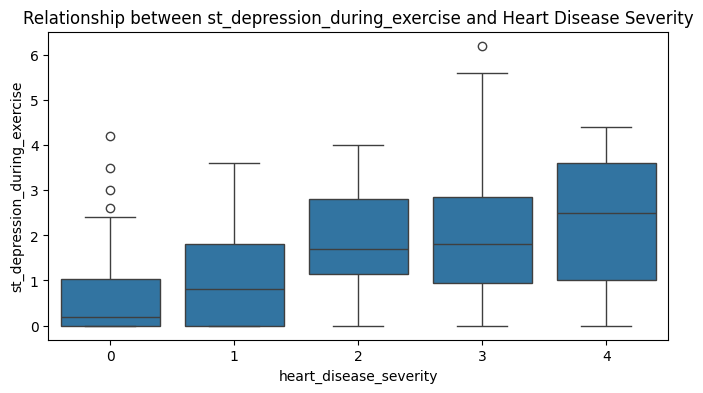

In [24]:
# List your continuous columns here
continuous_cols = ['age', 'resting_blood_pressure', 'cholesterol_level', 
                   'maximum_heart_rate_achieved', 'st_depression_during_exercise']

# Loop through and plot
for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='heart_disease_severity', y=col, data=data)
    plt.title(f'Relationship between {col} and Heart Disease Severity')
    plt.show()

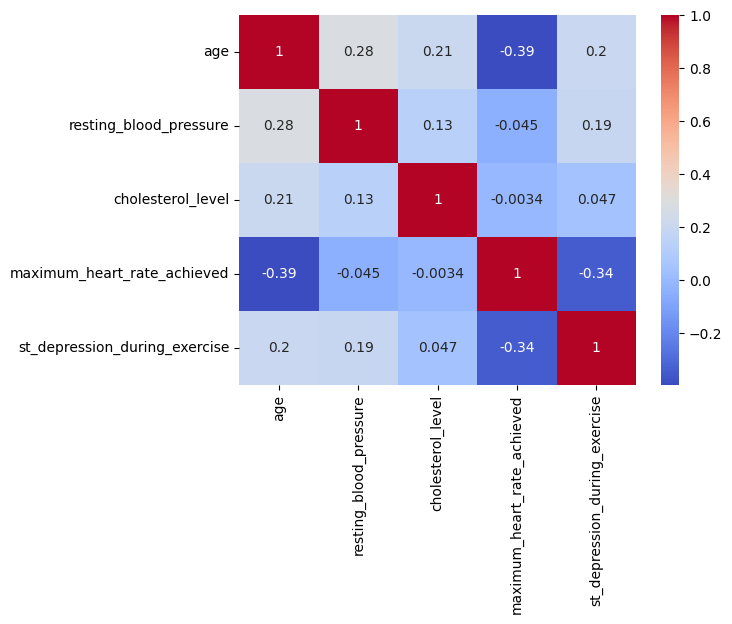

In [25]:
continuous_cols = ['age', 'resting_blood_pressure', 'cholesterol_level', 
                   'maximum_heart_rate_achieved', 'st_depression_during_exercise']
correlation_matrix = data[continuous_cols].corr()

# Now plot the heatmap using the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [26]:

numerical_cols = [
    'age',
    'resting_blood_pressure',
    'cholesterol_level',
    'maximum_heart_rate_achieved',
    'st_depression_during_exercise'
]

categorical_cols = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',
    'resting_ecg_result',
    'exercise_induced_chest_pain',
    'slope_of_exercise_ecg',
    'number_of_major_vessels',
    'thalassemia_test_result'
]

target_col = 'heart_disease_severity'

# Build X and y explicitly (previously X and Y were used without ever being defined -
# they only "worked" because of leftover variables from earlier, out-of-order runs,
# which is exactly what made the accuracy change between runs).
X = data[numerical_cols + categorical_cols].copy()
y = data[target_col].copy()

X.head()

,age,resting_blood_pressure,cholesterol_level,maximum_heart_rate_achieved,st_depression_during_exercise,sex,chest_pain_type,fasting_blood_sugar,resting_ecg_result,exercise_induced_chest_pain,slope_of_exercise_ecg,number_of_major_vessels,thalassemia_test_result
0,63.0,145.0,233.0,150.0,2.3,1.0,1.0,1.0,2.0,0.0,3.0,0.0,6.0
1,67.0,160.0,286.0,108.0,1.5,1.0,4.0,0.0,2.0,1.0,2.0,3.0,3.0
2,67.0,120.0,229.0,129.0,2.6,1.0,4.0,0.0,2.0,1.0,2.0,2.0,7.0
3,37.0,130.0,250.0,187.0,3.5,1.0,3.0,0.0,0.0,0.0,3.0,0.0,3.0
4,41.0,130.0,204.0,172.0,1.4,0.0,2.0,0.0,2.0,0.0,1.0,0.0,3.0


In [27]:
X[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sex                          303 non-null    float64
 1   chest_pain_type              303 non-null    float64
 2   fasting_blood_sugar          303 non-null    float64
 3   resting_ecg_result           303 non-null    float64
 4   exercise_induced_chest_pain  303 non-null    float64
 5   slope_of_exercise_ecg        303 non-null    float64
 6   number_of_major_vessels      303 non-null    float64
 7   thalassemia_test_result      303 non-null    float64
dtypes: float64(8)
memory usage: 19.1 KB


In [28]:
data['heart_disease_severity'].value_counts()

heart_disease_severity
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

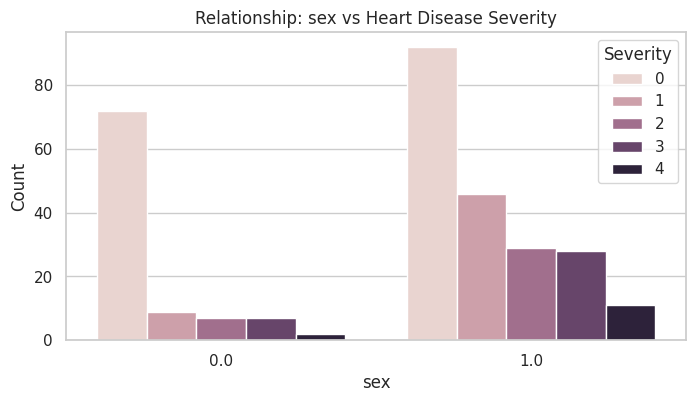

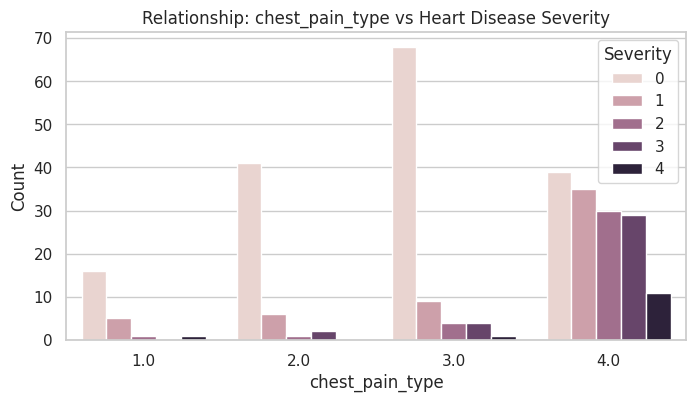

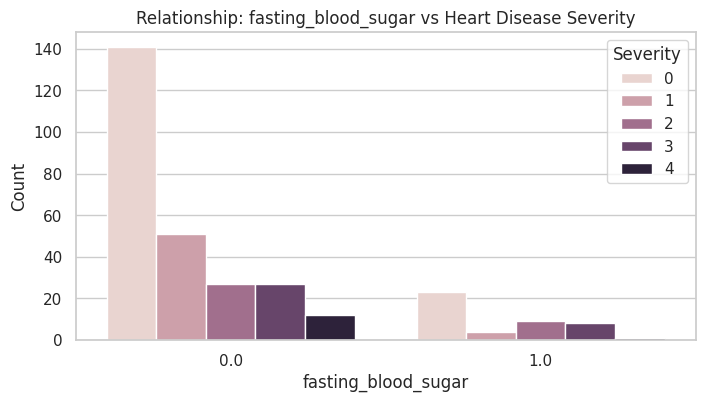

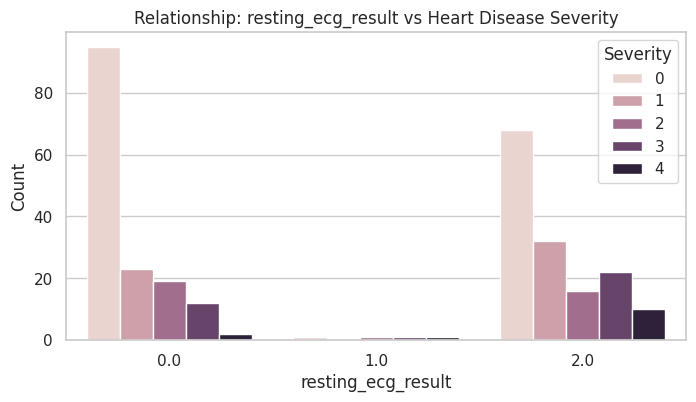

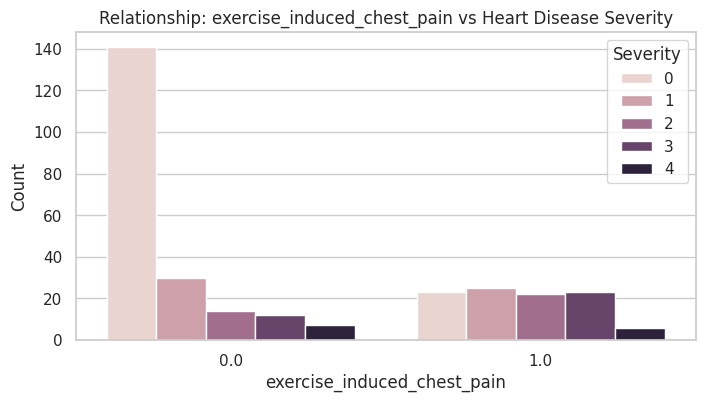

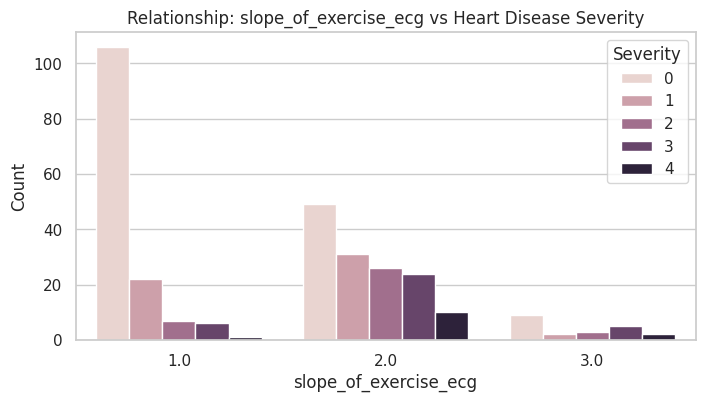

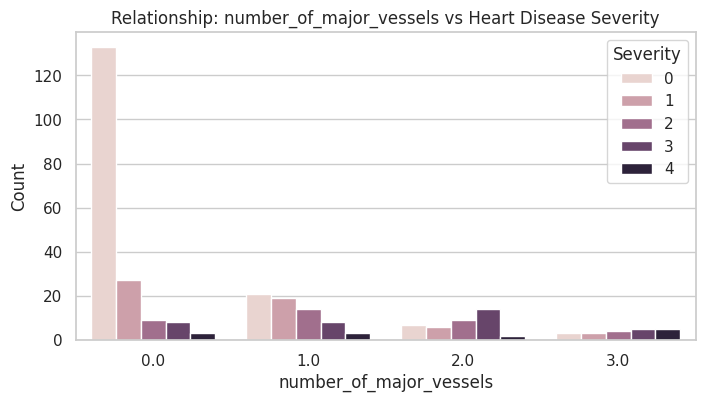

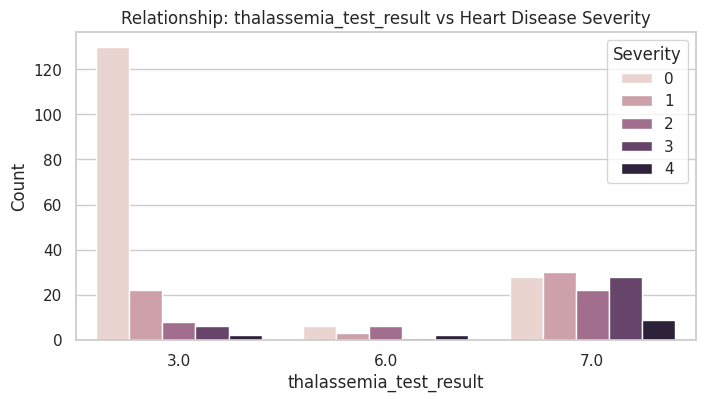

In [29]:
sns.set_theme(style="whitegrid")

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, hue='heart_disease_severity')
    plt.title(f'Relationship: {col} vs Heart Disease Severity')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Severity')
    plt.show()

**For Multi**

In [30]:
# # Keep the original severity levels 0-4 instead of collapsing to binary.
# # (0 = no disease, 1-4 = increasing severity)
# # Kept the variable name Y_binary so none of the downstream cells need to change.
# Y_binary = y.values

# unique, counts = np.unique(Y_binary, return_counts=True)
# print("Target Class Distribution:", dict(zip(unique, counts)))

**For Binary**

In [31]:
# 0 = no disease, 1-4 = disease present -> collapse to binary target
Y_binary = np.where(y > 0, 1, 0)

unique, counts = np.unique(Y_binary, return_counts=True)
print("Binary Target Distribution:", dict(zip(unique, counts)))

Binary Target Distribution: {np.int64(0): np.int64(164), np.int64(1): np.int64(139)}


In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y_binary,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=Y_binary
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (242, 13)
Testing set shape: (61, 13)


In [33]:
X_train.head()

,age,resting_blood_pressure,cholesterol_level,maximum_heart_rate_achieved,st_depression_during_exercise,sex,chest_pain_type,fasting_blood_sugar,resting_ecg_result,exercise_induced_chest_pain,slope_of_exercise_ecg,number_of_major_vessels,thalassemia_test_result
180,48.0,124.0,274.0,166.0,0.5,1.0,4.0,0.0,2.0,0.0,2.0,0.0,7.0
208,55.0,130.0,262.0,155.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0
167,54.0,132.0,288.0,159.0,0.0,0.0,2.0,1.0,2.0,1.0,1.0,1.0,3.0
105,54.0,108.0,309.0,156.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,7.0
297,57.0,140.0,241.0,123.0,0.2,0.0,4.0,0.0,0.0,1.0,2.0,0.0,7.0


For Binary XGBoost (eval_metric=logloss) and for multi XGBoost (eval_metric=mlogloss)

In [34]:
# Numerical columns -> StandardScaler
# Nominal columns -> OneHotEncoder
# Binary/ordinal columns -> passthrough
nominal_features = ['chest_pain_type', 'resting_ecg_result', 'thalassemia_test_result']
passthrough_features = [
    'sex', 'fasting_blood_sugar', 'exercise_induced_chest_pain',
    'slope_of_exercise_ecg', 'number_of_major_vessels'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), nominal_features),
        ('pass', 'passthrough', passthrough_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    # binary target -> eval_metric='logloss'. `use_label_encoder` was removed from modern
    # XGBoost and would raise an error if passed.eval_metric='logloss'(0, 1-4),mlogloss)9,1,2,3,4)
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

baseline_results = {}

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),  # SMOTE fit only inside each training fold/fit - no leakage
        ('classifier', model)
    ])

    pipeline.fit(X_train, Y_train)
    y_pred = pipeline.predict(X_test)

    baseline_results[name] = {
        'pipeline': pipeline,
        'accuracy': accuracy_score(Y_test, y_pred),
        'macro_f1': f1_score(Y_test, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(Y_test, y_pred, average='weighted', zero_division=0),
    }

    print(f"{name} (with SMOTE) Pipeline Test Accuracy: {baseline_results[name]['accuracy']:.4f}")

Logistic Regression (with SMOTE) Pipeline Test Accuracy: 0.9016
KNN (with SMOTE) Pipeline Test Accuracy: 0.8689
Decision Tree (with SMOTE) Pipeline Test Accuracy: 0.7377
Random Forest (with SMOTE) Pipeline Test Accuracy: 0.8525
XGBoost (with SMOTE) Pipeline Test Accuracy: 0.8689


In [35]:
for name, model in models.items():
    pipeline = baseline_results[name]['pipeline']
    y_pred = pipeline.predict(X_test)

    print(f"\n--- {name} (with SMOTE) Classification Report ---")
    print(classification_report(Y_test, y_pred))

    print(f"Macro Precision: {precision_score(Y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Macro Recall:    {recall_score(Y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Macro F1:        {f1_score(Y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Weighted Prec:   {precision_score(Y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Weighted Recall: {recall_score(Y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Weighted F1:     {f1_score(Y_test, y_pred, average='weighted', zero_division=0):.4f}")


--- Logistic Regression (with SMOTE) Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Macro Precision: 0.9011
Macro Recall:    0.9037
Macro F1:        0.9014
Weighted Prec:   0.9039
Weighted Recall: 0.9016
Weighted F1:     0.9018

--- KNN (with SMOTE) Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        33
           1       0.79      0.96      0.87        28

    accuracy                           0.87        61
   macro avg       0.88      0.88      0.87        61
weighted avg       0.89      0.87      0.87        61

Macro Precision: 0.8785
Macro Recall:    0.8761
Macro F1:        0.8688
Weighted Prec:   0

In [36]:
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(nominal_features)
all_feature_names = list(numerical_cols) + list(cat_feature_names) + list(passthrough_features)

tree_models = ["Decision Tree", "Random Forest", "XGBoost"]

for name in tree_models:
    pipeline = baseline_results[name]['pipeline']
    importances = pipeline.named_steps['classifier'].feature_importances_
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

    print(f"\n--- Top 5 Features: {name} ---")
    print(feat_imp.head(5))


--- Top 5 Features: Decision Tree ---
thalassemia_test_result_3.0      0.328467
number_of_major_vessels          0.112652
chest_pain_type_4.0              0.109360
cholesterol_level                0.093929
st_depression_during_exercise    0.076327
dtype: float64

--- Top 5 Features: Random Forest ---
number_of_major_vessels          0.104954
thalassemia_test_result_3.0      0.102072
maximum_heart_rate_achieved      0.100364
thalassemia_test_result_7.0      0.087539
st_depression_during_exercise    0.081828
dtype: float64

--- Top 5 Features: XGBoost ---
thalassemia_test_result_3.0    0.497344
chest_pain_type_1.0            0.110031
chest_pain_type_4.0            0.069555
number_of_major_vessels        0.064989
sex                            0.031524
dtype: float32


# Hyperparameter Tuning

**Logistic Regression**

In [37]:
lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])

log_reg_params = {
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs'],
    'classifier__max_iter': [1000]
}

grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=log_reg_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train, Y_train)

print(f"Best Parameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best F1 Weighted Score: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters for Logistic Regression: {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best F1 Weighted Score: 0.8381


In [38]:
y_pred_tuned = grid_search_lr.predict(X_test)

tuned_accuracy = accuracy_score(Y_test, y_pred_tuned)
tuned_macro_p = precision_score(Y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_macro_r = recall_score(Y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_macro_f1 = f1_score(Y_test, y_pred_tuned, average='macro', zero_division=0)
tuned_weighted_p = precision_score(Y_test, y_pred_tuned, average='weighted', zero_division=0)
tuned_weighted_r = recall_score(Y_test, y_pred_tuned, average='weighted', zero_division=0)
tuned_weighted_f1 = f1_score(Y_test, y_pred_tuned, average='weighted', zero_division=0)

print(f"Tuned Accuracy: {tuned_accuracy:.4f}")
print("\n--- Tuned Classification Report ---")
print(classification_report(Y_test, y_pred_tuned))

Tuned Accuracy: 0.8852

--- Tuned Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [39]:
best_lr_config = {
    "Model": "Logistic Regression",
    "Parameters": grid_search_lr.best_params_,
    "Accuracy": tuned_accuracy,
    "Macro F1": tuned_macro_f1,
    "Weighted F1": tuned_weighted_f1
}

print("Configuration Saved:")
for key, value in best_lr_config.items():
    print(f"{key}: {value}")

Configuration Saved:
Model: Logistic Regression
Parameters: {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Accuracy: 0.8852459016393442
Macro F1: 0.8851224105461393
Weighted F1: 0.8854311382791517


**Dicision Tree**

In [40]:
dt_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_params = {
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(dt_pipeline, dt_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_dt.fit(X_train, Y_train)

y_pred_dt = grid_dt.predict(X_test)
dt_acc = accuracy_score(Y_test, y_pred_dt)
dt_macro_f1 = f1_score(Y_test, y_pred_dt, average='macro', zero_division=0)
dt_weighted_f1 = f1_score(Y_test, y_pred_dt, average='weighted', zero_division=0)

print(f"Best DT Params: {grid_dt.best_params_}")
print(f"DT Accuracy: {dt_acc:.4f}, Macro F1: {dt_macro_f1:.4f}, Weighted F1: {dt_weighted_f1:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best DT Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
DT Accuracy: 0.7869, Macro F1: 0.7869, Weighted F1: 0.7869


In [41]:
print("\n--- Best Decision Tree Classification Report ---")
print(classification_report(Y_test, y_pred_dt))


--- Best Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



**Random Forest**

In [42]:
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_params = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(rf_pipeline, rf_params, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, Y_train)

y_pred_rf = grid_rf.predict(X_test)
rf_acc = accuracy_score(Y_test, y_pred_rf)
rf_macro_f1 = f1_score(Y_test, y_pred_rf, average='macro', zero_division=0)
rf_weighted_f1 = f1_score(Y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Best RF Params: {grid_rf.best_params_}")
print(f"RF Accuracy: {rf_acc:.4f}, Macro F1: {rf_macro_f1:.4f}, Weighted F1: {rf_weighted_f1:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF Params: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
RF Accuracy: 0.8852, Macro F1: 0.8851, Weighted F1: 0.8854


In [43]:
print("\n--- Best Random Forest Classification Report ---")
print(classification_report(Y_test, y_pred_rf))


--- Best Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



**K_Nearest Neighbour**

In [44]:
knn_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_knn.fit(X_train, Y_train)

print(f"Best KNN Params: {grid_search_knn.best_params_}")
print(f"Best KNN CV Accuracy: {grid_search_knn.best_score_:.4f}")

Best KNN Params: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}
Best KNN CV Accuracy: 0.8263


In [45]:
best_knn = grid_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
knn_acc = accuracy_score(Y_test, y_pred_knn)
knn_macro_f1 = f1_score(Y_test, y_pred_knn, average='macro', zero_division=0)
knn_weighted_f1 = f1_score(Y_test, y_pred_knn, average='weighted', zero_division=0)

print("\n--- Best KNN Classification Report ---")
print(classification_report(Y_test, y_pred_knn))
print(f"Macro F1: {knn_macro_f1:.4f}")
print(f"Weighted F1: {knn_weighted_f1:.4f}")


--- Best KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Macro F1: 0.8685
Weighted F1: 0.8691


**Comparison Table**

In [46]:
comparison_data = {
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "XGBoost", "Tuned Logistic Regression"],
    "Accuracy": [
        baseline_results["Logistic Regression"]["accuracy"],
        baseline_results["KNN"]["accuracy"],
        baseline_results["Decision Tree"]["accuracy"],
        baseline_results["Random Forest"]["accuracy"],
        baseline_results["XGBoost"]["accuracy"],
        tuned_accuracy,
    ],
    "Macro F1": [
        baseline_results["Logistic Regression"]["macro_f1"],
        baseline_results["KNN"]["macro_f1"],
        baseline_results["Decision Tree"]["macro_f1"],
        baseline_results["Random Forest"]["macro_f1"],
        baseline_results["XGBoost"]["macro_f1"],
        tuned_macro_f1,
    ],
    "Weighted F1": [
        baseline_results["Logistic Regression"]["weighted_f1"],
        baseline_results["KNN"]["weighted_f1"],
        baseline_results["Decision Tree"]["weighted_f1"],
        baseline_results["Random Forest"]["weighted_f1"],
        baseline_results["XGBoost"]["weighted_f1"],
        tuned_weighted_f1,
    ],
    "Best Parameters": ["Default", "Default", "Default", "Default", "Default", "Tuned"],
}

comparison_table = pd.DataFrame(comparison_data)
comparison_table["Accuracy"] = comparison_table["Accuracy"].map(lambda v: f"{v:.2%}")
print(comparison_table.to_string(index=False))

                    Model Accuracy  Macro F1  Weighted F1 Best Parameters
      Logistic Regression   90.16%  0.901401     0.901798         Default
                      KNN   86.89%  0.868817     0.868641         Default
            Decision Tree   73.77%  0.737634     0.737987         Default
            Random Forest   85.25%  0.852300     0.852697         Default
                  XGBoost   86.89%  0.868817     0.868993         Default
Tuned Logistic Regression   88.52%  0.885122     0.885431           Tuned


In [47]:
import numpy as np

# Use np.concatenate for numpy arrays
X = np.concatenate((X_train, X_test), axis=0)
Y = np.concatenate((Y_train, Y_test), axis=0)

print(f"X shape: {X.shape}, Y shape: {Y.shape}")

X shape: (303, 13), Y shape: (303,)


**cross validation Stability check**

In [48]:
print(type(X))

<class 'numpy.ndarray'>


**for Multi**

In [49]:
# # Rebuild X and Y_binary here explicitly so this cell doesn't depend on
# # whatever state earlier cells left X in.
# # FOR 0,1,2,3,4
# X = data[numerical_cols + categorical_cols].copy()
# Y_binary = y.values  # full 0-4 severity target

# final_model = LogisticRegression(**{k.replace('classifier__', ''): v
#                                      for k, v in grid_search_lr.best_params_.items()},
#                                   random_state=RANDOM_STATE)

# cv_pipeline = ImbPipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('smote', SMOTE(random_state=RANDOM_STATE)),
#     ('classifier', final_model)
# ])

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# scores = cross_val_score(cv_pipeline, X, Y_binary, cv=skf, scoring='accuracy')

# print(f"Stratified 5-Fold Accuracy Scores: {scores}")
# print(f"Mean Accuracy: {scores.mean():.4f}")
# print(f"Standard Deviation: {scores.std():.4f}")

# if scores.std() < 0.05:
#     print("Result: The model is stable and consistent across different data splits.")
# else:
#     print("Result: The model shows some variance; consider further data collection or feature refinement.")

**For Binary**

In [50]:
# Rebuild X and Y_binary here explicitly so this cell doesn't depend on
# whatever state earlier cells left X in.
# for 0, 1-4(convert to binary)
X = data[numerical_cols + categorical_cols].copy()
Y_binary = np.where(y > 0, 1, 0)

final_model = LogisticRegression(**{k.replace('classifier__', ''): v
                                     for k, v in grid_search_lr.best_params_.items()},
                                  random_state=RANDOM_STATE)

cv_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', final_model)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(cv_pipeline, X, Y_binary, cv=skf, scoring='accuracy')

print(f"Stratified 5-Fold Accuracy Scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

if scores.std() < 0.05:
    print("Result: The model is stable and consistent across different data splits.")
else:
    print("Result: The model shows some variance; consider further data collection or feature refinement.")

Stratified 5-Fold Accuracy Scores: [0.90163934 0.81967213 0.81967213 0.8        0.86666667]
Mean Accuracy: 0.8415
Standard Deviation: 0.0372
Result: The model is stable and consistent across different data splits.


**Confusion metrics( tunned Logistic regression)**

**For Multi**

In [51]:
# # Uses y_pred_tuned, computed earlier from grid_search_lr on X_test - not a stale
# # variable left over from another model's loop. 0,1,2,3,4
# cm_multi = confusion_matrix(Y_test, y_pred_tuned)
# class_labels = sorted(np.unique(Y_test))

# fig, ax = plt.subplots(figsize=(7, 6))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=class_labels)
# disp.plot(cmap=plt.cm.Blues, ax=ax)
# plt.title("Confusion Matrix: Logistic Regression (0-4 Severity, Tuned)")
# plt.show()

**For Binary**

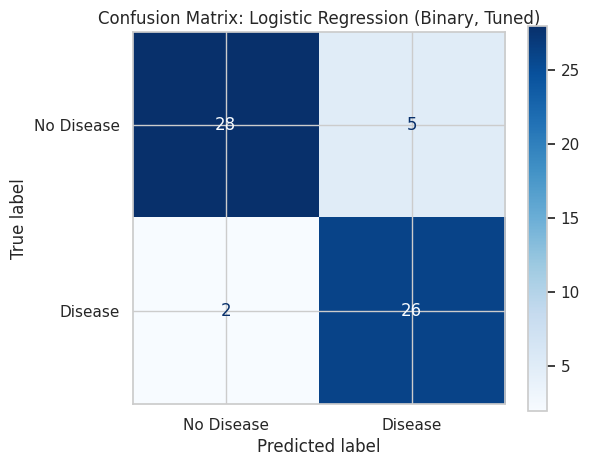

In [52]:
# Uses y_pred_tuned, computed earlier from grid_search_lr on X_test - not a stale
# variable left over from another model's loop.0,1-4
# for 0, 1-4(convert to binary)
cm_bin = confusion_matrix(Y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["No Disease", "Disease"])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix: Logistic Regression (Binary, Tuned)")
plt.show()

**final summary**

In [53]:
summary = pd.DataFrame({
    "Item": ["Best Model", "Hyperparameter Tuning", "SMOTE", "Cross Validation",
             "Mean CV Accuracy", "Test Accuracy", "Macro F1", "Weighted F1"],
    "Value": ["Logistic Regression", "Yes", "Yes", "Stratified 5-Fold",
              f"{scores.mean():.2%}", f"{tuned_accuracy:.2%}",
              f"{tuned_macro_f1:.3f}", f"{tuned_weighted_f1:.3f}"]
})
print(summary.to_string(index=False))

                 Item               Value
           Best Model Logistic Regression
Hyperparameter Tuning                 Yes
                SMOTE                 Yes
     Cross Validation   Stratified 5-Fold
     Mean CV Accuracy              84.15%
        Test Accuracy              88.52%
             Macro F1               0.885
          Weighted F1               0.885


**Saving the model**

In [54]:
model_filename = 'final_tuned_2_logistic_regression.pkl'
joblib.dump(grid_search_lr.best_estimator_, model_filename)
print(f"Model saved successfully as {model_filename}")

Model saved successfully as final_tuned_2_logistic_regression.pkl
